# Mammography Dataset Analysis Using Deep Learning

## Overview

This project focuses on abnormality detection in the Mammography dataset using deep learning and adaptive learning strategies on a highly imbalanced medical dataset.

The workflow includes:
- dataset preprocessing,
- handling class imbalance,
- model training,
- uncertainty-based adaptive learning,
- and performance evaluation.

## Dataset

The Mammography dataset contains normal and abnormal samples used for binary classification of breast tissue abnormalities.

## Tools and Libraries

- PyTorch
- NumPy
- Pandas
- Scikit-learn
- Matplotlib

## Evaluation Metrics

Models are evaluated using:
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC
- PR-AUC

# Import Libraries and Environment Setup

This section imports all the required libraries for data processing, visualization, machine learning, and deep learning operations.

Additionally:
- random seeds are initialized for reproducibility,
- GPU/CPU device configuration is detected,
- and directories for saving output figures are created.

In [3]:
# ==============================
# 1. IMPORTS
# ==============================
import os
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import *

# Create folder for figures
os.makedirs("figures", exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ==============================
# SEED (for reproducibility)
# ==============================
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

Device: cuda


# Dataset Loading and Preparation

The mammography dataset is loaded and prepared for model training.  
This includes:
- loading the dataset,
- separating features and target labels,
- analyzing class imbalance,
- train-test splitting,
- feature scaling,
- and tensor conversion for PyTorch.

In [4]:
# ==============================
# 2. LOAD DATA
# ==============================
from scipy.io import loadmat

data = loadmat("mammography.mat")


X = data['X']
y = data['y'].ravel()

y = y.astype(int)

print("Shape:", X.shape)
print("Class distribution:", np.bincount(y))
print("Normal vs Fraud (%):", np.bincount(y) / len(y) * 100)
print(f"Imbalance Ratio (Normal:Fraud) = {np.bincount(y)[0]}:{np.bincount(y)[1]}")

Shape: (11183, 6)
Class distribution: [10923   260]
Normal vs Fraud (%): [97.67504248  2.32495752]
Imbalance Ratio (Normal:Fraud) = 10923:260


# Train-Test Split

The dataset is divided into training and testing sets while maintaining class distribution using stratified sampling.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Feature Scaling and Tensor Conversion

Feature scaling is applied using StandardScaler to normalize the input features.

The processed data is then converted into PyTorch tensors for deep learning model training.

In [6]:
# ==============================
# 3. SCALING
# ==============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ==============================
# 4. TORCH DATA
# ==============================
X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.long).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)

# Deep Learning Model Architecture

A fully connected neural network (FCNN) is developed using PyTorch for binary classification of normal and fraudulent transactions.

The architecture consists of:
- multiple dense layers,
- ReLU activation functions,
- and dropout layers for regularization and overfitting prevention.

In [7]:
# ==============================
# 5. MODEL
# ==============================
class Net(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)


# PSI-Based Uncertainty Function

A custom PSI (Population Stability Index)-based function is implemented to measure distributional changes between probability predictions.

This function helps quantify:
- distribution drift,
- uncertainty behavior,
- and class-wise probability variations during model learning.

In [8]:

# ==============================
# 6. PSI FUNCTION
# ==============================
def compute_du_dl(p_prev, p_curr, y_true):
    du, dl = 0.0, 0.0
    for j in range(len(p_curr)):
        p_prev_j = np.clip(p_prev[j], 1e-10, 1-1e-10)
        p_curr_j = np.clip(p_curr[j], 1e-10, 1-1e-10)

        delta = p_curr_j - p_prev_j
        log_ratio = np.log(p_curr_j / p_prev_j)
        val = delta * log_ratio

        if j == y_true:
            if delta < 0: du += val
            else: dl += val
        else:
            if delta > 0: du += val
            else: dl += val

    return du, dl

# Proposed Training Framework Based on Research Paper

The proposed training framework introduces an adaptive sample-weighting mechanism based on PSI-driven difficulty estimation.

During training:
- sample difficulty scores are dynamically updated,
- training weights are adjusted iteratively,
- and harder samples receive increased importance during learning.

The framework combines:
- neural network training,
- uncertainty-based weighting,
- and adaptive probability updating for improved fraud detection performance on imbalanced datasets.

In [9]:
# ==============================
# 7. PROPOSED METHOD (MAIN)
# ==============================
def paper_training_strict(epochs=100, batch_size=512, c=1.0):

    n = len(X_train)
    model = Net(X_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    weights = np.ones(n) / n
    prev_probs = np.full((n, 2), 0.5)

    du_sum = np.zeros(n)
    dl_sum = np.zeros(n)

    loss_history = []

    for epoch in range(1, epochs + 1):

        model.train()
        epoch_loss = 0

        for _ in range(n // batch_size):

            weights = np.clip(weights, 1e-6, None)
            weights /= weights.sum()

            idx = np.random.choice(np.arange(n), batch_size, p=weights)

            Xb = X_train_t[idx]
            yb = y_train_t[idx]

            optimizer.zero_grad()
            out = model(Xb)

            loss = nn.CrossEntropyLoss(label_smoothing=0.05)(out, yb)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()  # accumulate

        # average loss
        epoch_loss /= (n // batch_size)
        loss_history.append(epoch_loss)

        # difficulty update
        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(X_train_t), dim=1).cpu().numpy()

        for i in range(n):
            du, dl = compute_du_dl(prev_probs[i], probs[i], y_train[i])
            du_sum[i] += du
            dl_sum[i] += dl

        difficulty = (c + du_sum) / (c + dl_sum + 1e-8)
        difficulty = np.clip(difficulty, 1e-5, 50)

        weights = difficulty / difficulty.sum()
        prev_probs = probs.copy()

        if epoch % 5 == 0:
            print(f"Epoch {epoch}, Loss: {epoch_loss:.4f}")

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(X_test_t), dim=1)[:, 1].cpu().numpy()

    return probs, loss_history

# Class-Weighted Training Framework

An additional experiment is performed using class-weighted loss optimization to address severe class imbalance.

Class weights are automatically computed from the training dataset and incorporated into the cross-entropy loss function to increase the importance of minority class samples during learning.

This experiment evaluates the impact of combining:
- adaptive sample weighting,
- PSI-based difficulty estimation,
- and class-balanced optimization.

In [10]:
# ==============================
# 7B. CLASS-WEIGHTED (EXPERIMENT)
# ==============================
def paper_training_weighted(epochs=100, batch_size=512, c=1.0):

    n = len(X_train)
    model = Net(X_train.shape[1]).to(device)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    # sampling weights
    sample_weights = np.ones(n) / n
    prev_probs = np.full((n, 2), 0.5)

    du_sum = np.zeros(n)
    dl_sum = np.zeros(n)

    loss_history = []

    # compute class weights
    from sklearn.utils.class_weight import compute_class_weight

    cw = compute_class_weight(
        class_weight='balanced',
        classes=np.unique(y_train),
        y=y_train
    )

    class_weights = torch.tensor(cw, dtype=torch.float32).to(device)

    for epoch in range(1, epochs + 1):

        model.train()
        epoch_loss = 0

        for _ in range(n // batch_size):

            # use sample_weights here
            sample_weights = np.clip(sample_weights, 1e-6, None)
            sample_weights /= sample_weights.sum()

            idx = np.random.choice(np.arange(n), batch_size, p=sample_weights)

            Xb = X_train_t[idx]
            yb = y_train_t[idx]

            optimizer.zero_grad()
            out = model(Xb)

            loss = nn.CrossEntropyLoss(
                weight=class_weights,
                label_smoothing=0.05
            )(out, yb)

            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        epoch_loss /= (n // batch_size)
        loss_history.append(epoch_loss)

        # difficulty update
        model.eval()
        with torch.no_grad():
            probs = torch.softmax(model(X_train_t), dim=1).cpu().numpy()

        for i in range(n):
            du, dl = compute_du_dl(prev_probs[i], probs[i], y_train[i])
            du_sum[i] += du
            dl_sum[i] += dl

        difficulty = (c + du_sum) / (c + dl_sum + 1e-8)
        difficulty = np.clip(difficulty, 1e-5, 50)

        sample_weights = difficulty / difficulty.sum()
        prev_probs = probs.copy()

        if epoch % 5 == 0:
            print(f"[Weighted] Epoch {epoch}, Loss: {epoch_loss:.4f}")

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(X_test_t), dim=1)[:, 1].cpu().numpy()

    return probs, loss_history


# Baseline Machine Learning Models

To compare the effectiveness of the proposed framework, several traditional machine learning models are implemented as baseline classifiers.

The selected baseline models include:
- Logistic Regression,
- Support Vector Machine (SVM),
- and Random Forest.

These models provide benchmark performance for comparison against the proposed deep learning-based approach.

In [11]:
# ==============================
# 8. BASELINES
# ==============================
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

def eval_model(model):
    model.fit(X_train, y_train)

    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_test)[:, 1]
    else:
        return model.decision_function(X_test)

# Proposed Framework Execution

The proposed PSI-based adaptive learning framework and its class-weighted variant are trained and evaluated.

In [12]:

# ==============================
# 9. RUN
# ==============================
results = {}

results["Logistic"] = eval_model(LogisticRegression(max_iter=2000))
results["SVM"] = eval_model(SVC(probability=True))
results["RF"] = eval_model(RandomForestClassifier(n_estimators=200))

# Proposed
probs_main, loss_main = paper_training_strict()
results["Proposed"] = probs_main

# Weighted
probs_w, loss_w = paper_training_weighted()
results["Proposed_Weighted"] = probs_w

Epoch 5, Loss: 0.2327
Epoch 10, Loss: 0.2110
Epoch 15, Loss: 0.2059
Epoch 20, Loss: 0.1942
Epoch 25, Loss: 0.1918
Epoch 30, Loss: 0.1914
Epoch 35, Loss: 0.1809
Epoch 40, Loss: 0.1773
Epoch 45, Loss: 0.1781
Epoch 50, Loss: 0.1793
Epoch 55, Loss: 0.1724
Epoch 60, Loss: 0.1791
Epoch 65, Loss: 0.1710
Epoch 70, Loss: 0.1685
Epoch 75, Loss: 0.1692
Epoch 80, Loss: 0.1708
Epoch 85, Loss: 0.1691
Epoch 90, Loss: 0.1646
Epoch 95, Loss: 0.1683
Epoch 100, Loss: 0.1675
[Weighted] Epoch 5, Loss: 0.9757
[Weighted] Epoch 10, Loss: 0.9794
[Weighted] Epoch 15, Loss: 0.9807
[Weighted] Epoch 20, Loss: 0.9338
[Weighted] Epoch 25, Loss: 0.9465
[Weighted] Epoch 30, Loss: 0.9309
[Weighted] Epoch 35, Loss: 0.8917
[Weighted] Epoch 40, Loss: 0.9819
[Weighted] Epoch 45, Loss: 0.9284
[Weighted] Epoch 50, Loss: 0.9266
[Weighted] Epoch 55, Loss: 0.9119
[Weighted] Epoch 60, Loss: 0.8787
[Weighted] Epoch 65, Loss: 0.9348
[Weighted] Epoch 70, Loss: 0.9304
[Weighted] Epoch 75, Loss: 0.9449
[Weighted] Epoch 80, Loss: 0.91

# Ensemble Learning Experiment

An additional ensemble experiment is performed to improve prediction robustness and model stability.

Multiple instances of the proposed framework are independently trained, and their prediction probabilities are averaged to generate the final ensemble output.

This approach helps:
- reduce prediction variance,
- improve generalization,
- and enhance fraud detection performance.

In [13]:
# ==============================
# 9B. ENSEMBLE (EXTRA EXPERIMENT)
# ==============================
print("\nTraining Ensemble Models...\n")

ensemble_probs = []
ensemble_losses = []

for i in range(3):
    print(f"Training model {i+1}/3...")

    prob, loss = paper_training_strict()

    ensemble_probs.append(prob)
    ensemble_losses.append(loss)

# Average predictions
ensemble_prob = np.mean(ensemble_probs, axis=0)
results["Proposed_Ensemble"] = ensemble_prob

# Average loss curve
ensemble_loss = np.mean(ensemble_losses, axis=0)



Training Ensemble Models...

Training model 1/3...
Epoch 5, Loss: 0.2214
Epoch 10, Loss: 0.1944
Epoch 15, Loss: 0.1894
Epoch 20, Loss: 0.1821
Epoch 25, Loss: 0.1844
Epoch 30, Loss: 0.1788
Epoch 35, Loss: 0.1740
Epoch 40, Loss: 0.1746
Epoch 45, Loss: 0.1714
Epoch 50, Loss: 0.1751
Epoch 55, Loss: 0.1701
Epoch 60, Loss: 0.1711
Epoch 65, Loss: 0.1740
Epoch 70, Loss: 0.1677
Epoch 75, Loss: 0.1685
Epoch 80, Loss: 0.1685
Epoch 85, Loss: 0.1632
Epoch 90, Loss: 0.1627
Epoch 95, Loss: 0.1525
Epoch 100, Loss: 0.1650
Training model 2/3...
Epoch 5, Loss: 0.2335
Epoch 10, Loss: 0.2018
Epoch 15, Loss: 0.1897
Epoch 20, Loss: 0.1879
Epoch 25, Loss: 0.1857
Epoch 30, Loss: 0.1858
Epoch 35, Loss: 0.1861
Epoch 40, Loss: 0.1762
Epoch 45, Loss: 0.1828
Epoch 50, Loss: 0.1805
Epoch 55, Loss: 0.1736
Epoch 60, Loss: 0.1773
Epoch 65, Loss: 0.1753
Epoch 70, Loss: 0.1751
Epoch 75, Loss: 0.1714
Epoch 80, Loss: 0.1665
Epoch 85, Loss: 0.1672
Epoch 90, Loss: 0.1623
Epoch 95, Loss: 0.1655
Epoch 100, Loss: 0.1660
Traini

# Threshold Optimization and Model Evaluation

This section performs threshold optimization and evaluates the performance of all baseline and proposed models.

An optimal classification threshold is selected using F1-score maximization to improve prediction performance on the highly imbalanced dataset.

The models are evaluated using:
- Accuracy
- Precision
- Recall
- F1-score

Additionally, predicted class distributions are analyzed to examine the classification behavior of each model on normal and fraudulent samples.

In [14]:
# ==============================
# 10. THRESHOLD + METRICS
# ==============================
def best_threshold(y, prob):
    best_f1, best_t = 0, 0.5
    for t in np.linspace(0.01, 0.99, 100):
        f1 = f1_score(y, (prob > t), zero_division=0)
        if f1 > best_f1:
            best_f1, best_t = f1, t
    return best_t

metrics = {}
preds_all = {}

for name, prob in results.items():
    t = best_threshold(y_test, prob)
    preds = (prob > t).astype(int)
    preds_all[name] = preds

    metrics[name] = {
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0)
    }

print("\nFINAL RESULTS:\n")
print(pd.DataFrame(metrics).T)

print("\nPREDICTED CLASS DISTRIBUTION (%):\n")

for name, preds in preds_all.items():
    counts = np.bincount(preds)

    if len(counts) < 2:
        counts = np.append(counts, 0)

    total = counts.sum()

    print(f"{name}:")
    print(f"  Normal (0): {counts[0]} ({counts[0]/total*100:.2f}%)")
    print(f"  Fraud  (1): {counts[1]} ({counts[1]/total*100:.2f}%)")
    print("-" * 40)


FINAL RESULTS:

                   Accuracy  Precision    Recall        F1
Logistic           0.981818   0.602410  0.641026  0.621118
SVM                0.984799   0.666667  0.692308  0.679245
RF                 0.988376   0.767123  0.717949  0.741722
Proposed           0.987481   0.730769  0.730769  0.730769
Proposed_Weighted  0.987779   0.722892  0.769231  0.745342
Proposed_Ensemble  0.988972   0.797101  0.705128  0.748299

PREDICTED CLASS DISTRIBUTION (%):

Logistic:
  Normal (0): 3272 (97.53%)
  Fraud  (1): 83 (2.47%)
----------------------------------------
SVM:
  Normal (0): 3274 (97.59%)
  Fraud  (1): 81 (2.41%)
----------------------------------------
RF:
  Normal (0): 3282 (97.82%)
  Fraud  (1): 73 (2.18%)
----------------------------------------
Proposed:
  Normal (0): 3277 (97.68%)
  Fraud  (1): 78 (2.32%)
----------------------------------------
Proposed_Weighted:
  Normal (0): 3272 (97.53%)
  Fraud  (1): 83 (2.47%)
----------------------------------------
Proposed_Ensembl

# Performance Visualization and Analysis

This section presents graphical evaluation and performance analysis of the baseline and proposed models.

The following visualizations are generated:
- ROC curves,
- Precision-Recall curves,
- confusion matrices,
- class distribution plots,
- training loss comparison,
- and precision-recall behavior across classification thresholds.

These visualizations provide deeper insight into:
- classification performance,
- model learning behavior,
- threshold sensitivity,
- and fraud detection capability on the imbalanced dataset.

All figures are automatically saved for further report and presentation use.

In [15]:
# ==============================
# CREATE FIGURE DIRECTORY
# ==============================
import os
os.makedirs("figures", exist_ok=True)


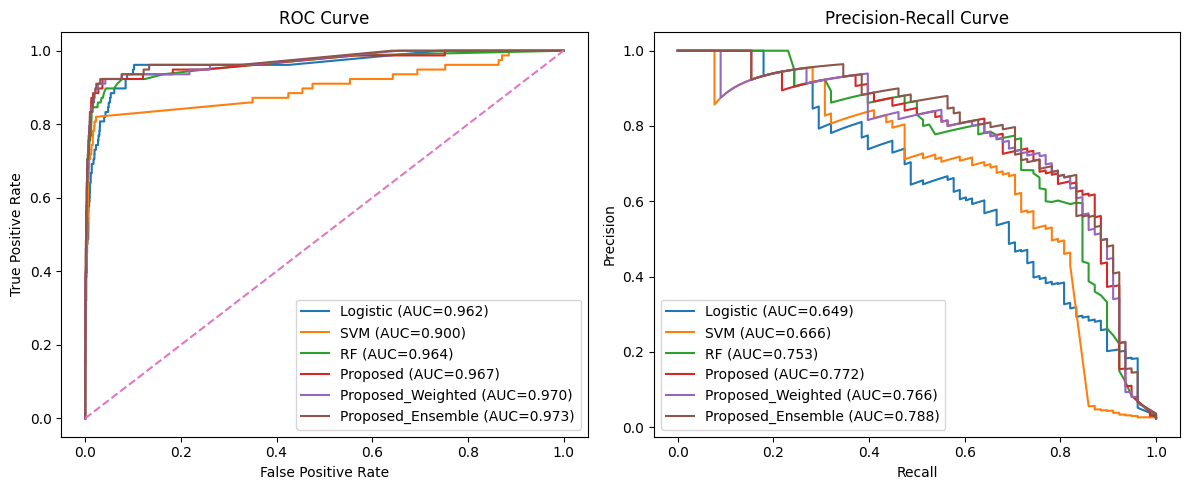

In [16]:
# ============================================================
# 11. ROC AND PR CURVE VISUALIZATION
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12,5))

# ===== ROC =====
for name, prob in results.items():

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    axes[0].plot(
        fpr,
        tpr,
        label=f"{name} (AUC={roc_auc:.3f})"
    )

axes[0].plot([0,1],[0,1],'--')

axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[0].set_title("ROC Curve")

axes[0].legend()


# ===== PR =====
for name, prob in results.items():

    precision, recall, _ = precision_recall_curve(y_test, prob)
    pr_auc = auc(recall, precision)

    axes[1].plot(
        recall,
        precision,
        label=f"{name} (AUC={pr_auc:.3f})"
    )

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

axes[1].set_title("Precision-Recall Curve")

axes[1].legend()

plt.tight_layout()

plt.savefig(
    "figures/mammo_roc_pr.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


In [17]:
# ============================================================
# 12. ROC-AUC AND PR-AUC VALUES
# ============================================================
print("\nAUC VALUES:\n")

for name, prob in results.items():

    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)

    precision, recall, _ = precision_recall_curve(y_test, prob)
    pr_auc = auc(recall, precision)

    print(
        f"{name}: ROC-AUC = {roc_auc:.4f}, "
        f"PR-AUC = {pr_auc:.4f}"
    )


AUC VALUES:

Logistic: ROC-AUC = 0.9619, PR-AUC = 0.6490
SVM: ROC-AUC = 0.8999, PR-AUC = 0.6659
RF: ROC-AUC = 0.9637, PR-AUC = 0.7530
Proposed: ROC-AUC = 0.9668, PR-AUC = 0.7717
Proposed_Weighted: ROC-AUC = 0.9696, PR-AUC = 0.7656
Proposed_Ensemble: ROC-AUC = 0.9734, PR-AUC = 0.7884


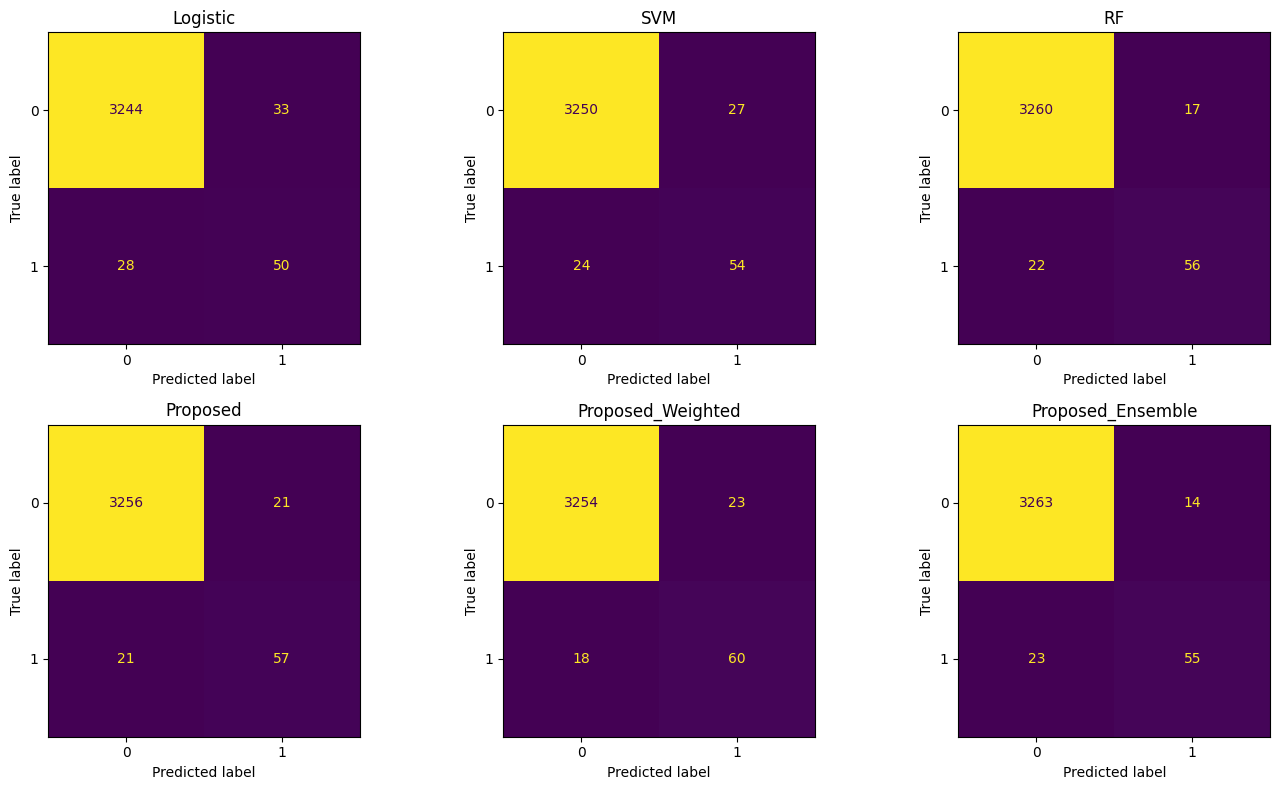

In [18]:
# ============================================================
# 13. CONFUSION MATRIX VISUALIZATION
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14,8))

axes = axes.flatten()

for ax, (name, preds) in zip(axes, preds_all.items()):

    cm = confusion_matrix(y_test, preds)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm
    )

    disp.plot(
        ax=ax,
        colorbar=False
    )

    ax.set_title(name)

plt.tight_layout()

plt.savefig(
    "figures/mammo_confusion.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()


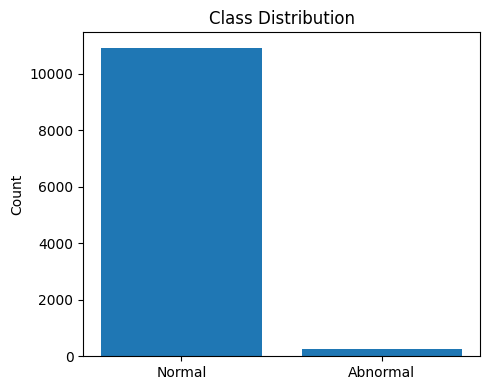

In [19]:
# ============================================================
# 14. CLASS DISTRIBUTION VISUALIZATION
# ============================================================
plt.figure(figsize=(5,4))

counts = np.bincount(y)

plt.bar(
    ["Normal", "Abnormal"],
    counts
)

plt.title("Class Distribution")
plt.ylabel("Count")

plt.tight_layout()

plt.savefig(
    "figures/mammo_class_distribution.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()



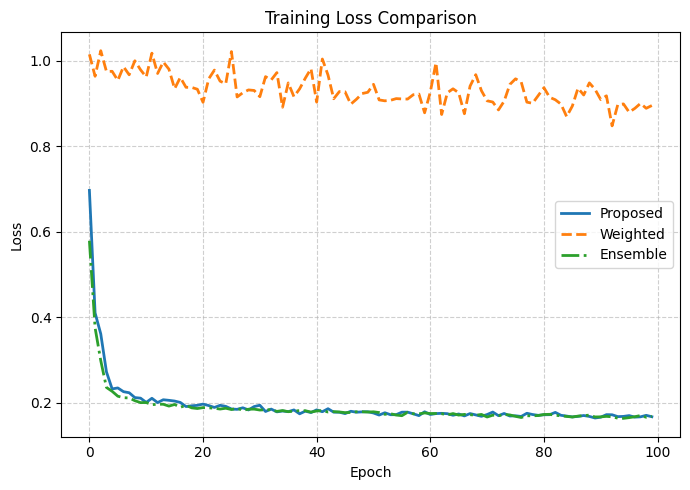

In [20]:
# ============================================================
# 15. TRAINING LOSS COMPARISON
# ============================================================
plt.figure(figsize=(7,5))

plt.plot(
    loss_main,
    label="Proposed",
    linestyle='-',
    linewidth=2
)

plt.plot(
    loss_w,
    label="Weighted",
    linestyle='--',
    linewidth=2
)

plt.plot(
    ensemble_loss,
    label="Ensemble",
    linestyle='-.',
    linewidth=2
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training Loss Comparison")

plt.legend()

plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    "figures/mammo_loss.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()



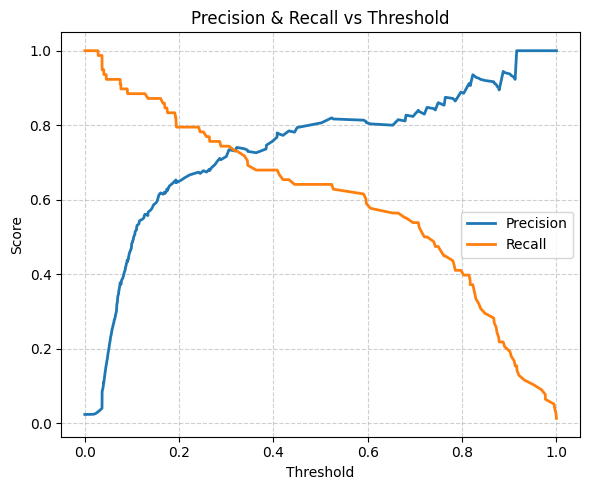

In [21]:

# ============================================================
# 16. PRECISION-RECALL VS THRESHOLD
# ============================================================
prob = results["Proposed"]

precision, recall, thresholds = precision_recall_curve(
    y_test,
    prob
)

plt.figure(figsize=(6,5))

plt.plot(
    thresholds,
    precision[:-1],
    label="Precision",
    linewidth=2
)

plt.plot(
    thresholds,
    recall[:-1],
    label="Recall",
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Score")

plt.title("Precision & Recall vs Threshold")

plt.legend()

plt.grid(
    True,
    linestyle='--',
    alpha=0.6
)

plt.tight_layout()

plt.savefig(
    "figures/mammo_threshold_curve.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()